In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import (norm, bernoulli, binom, poisson, expon, beta as beta_dist, multivariate_normal)

In [4]:
omega = [(i, j) for i in range(1, 7) for j in range(1, 7)]
print(f'Omega = {len(omega)} outcomes')

Omega = 36 outcomes


In [5]:
print(omega)

[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


In [6]:
A = {(i , j) for i in range(1, 7) for j in range(1, 7) if i+j <= 7}
B = {(i , j) for i in range(1, 7) for j in range(1, 7) if i+j >= 10}

print(A)
print(B)

{(3, 4), (4, 3), (3, 1), (5, 1), (2, 2), (1, 6), (2, 5), (1, 3), (4, 2), (3, 3), (2, 4), (1, 2), (2, 1), (1, 5), (6, 1), (3, 2), (4, 1), (5, 2), (1, 1), (1, 4), (2, 3)}
{(5, 5), (6, 5), (4, 6), (6, 4), (5, 6), (6, 6)}


In [9]:
print(f'P(A) = {len(A)/len(omega)}')
print(f'P(B) = {len(B)/len(omega)}')

print(f'P(AUB) = {len(A.union(B))/len(omega)}')
print(f'P(AnB) = {len(A.intersection(B))/len(omega)}')

P(A) = 0.5833333333333334
P(B) = 0.16666666666666666
P(AUB) = 0.75
P(AnB) = 0.0


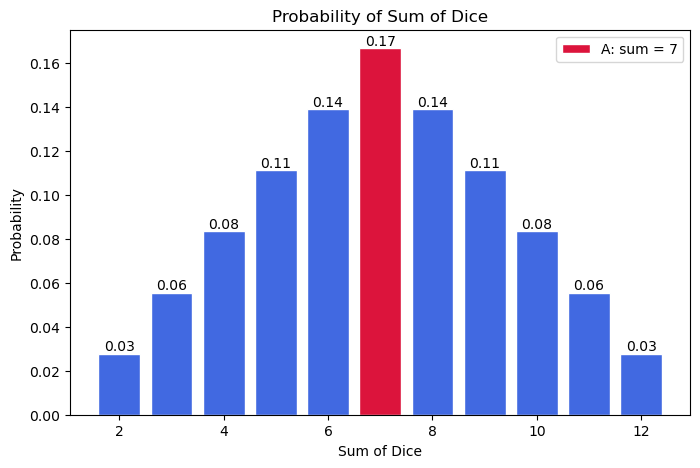

In [17]:
sum_vals = [i + j for i, j in omega]

vals, counts = np.unique(sum_vals, return_counts=True)
probs = counts / len(omega)

PALETTE = ['royalblue', 'crimson']
fig, ax = plt.subplots(figsize=(8, 5))

# Plot all bars
bars = ax.bar(vals, probs, color=PALETTE[0], edgecolor='white')

# Highlight sum = 7
mask = vals == 7
ax.bar(vals[mask], probs[mask],
       color=PALETTE[1],
       edgecolor='white',
       label='A: sum = 7')

# Add probability labels
for bar, prob in zip(bars, probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{prob:.2f}',
        ha='center',
        va='bottom'
    )

ax.set_xlabel('Sum of Dice')
ax.set_ylabel('Probability')
ax.set_title('Probability of Sum of Dice')

plt.legend()
plt.show()

In [21]:
p_spam, p_ham = 0.10, 0.90
p_flag_spam = 0.95
p_flag_ham = 0.02

p_flag = p_flag_spam * p_spam/((p_flag_spam*p_spam) + (p_flag_ham * p_ham))
p_spam_given_flag = (p_flag_spam * p_spam)/p_flag

### Probablity Distribution

5.125
4.696428571428571
4.109375
2.1671244937540095
Z-score for data[0] = -1.442
Z-score for data[1] = -0.519
Z-score for data[2] = -0.519
Z-score for data[3] = -0.519
Z-score for data[4] = -0.058
Z-score for data[5] = 0.404
Z-score for data[6] = 0.865
Z-score for data[7] = 1.788
5.551115123125783e-17
0.9354143466934854


C:\Users\Atharva\AppData\Local\Temp\ipykernel_16112\286533387.py:24: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  axes[0].stem(data, use_line_collection=True)


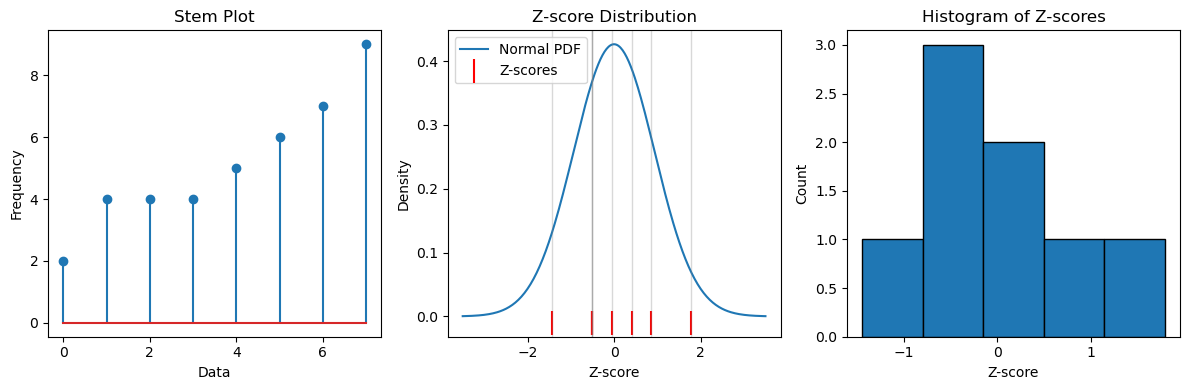

In [33]:
data = np.array([2, 4, 4, 4, 5, 6, 7, 9])

mu = np.mean(data)
var = np.var(data, ddof=1)
a_var = np.var(data, ddof=0)
sigma = np.std(data, ddof=1)

z_score = (data - mu) / sigma

print(mu)
print(var)
print(a_var)
print(sigma)

for i in range(len(data)):
    print(f'Z-score for data[{i}] = {z_score[i]:.3f}')

print(np.mean(z_score))
print(np.std(z_score))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Stem plot
axes[0].stem(data, use_line_collection=True)
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Stem Plot")

# Normal distribution plot
x_range = np.linspace(-3.5, 3.5, 300)

axes[1].plot(
    x_range,
    norm.pdf(x_range, np.mean(z_score), np.std(z_score)),
    label='Normal PDF'
)

axes[1].scatter(
    z_score,
    np.full_like(z_score, -0.01),
    marker='|',
    s=300,
    color='red',
    label='Z-scores'
)

for z in z_score:
    axes[1].axvline(z, color='gray', alpha=0.3, lw=1)

axes[1].set_title("Z-score Distribution")
axes[1].set_ylabel("Density")
axes[1].set_xlabel("Z-score")
axes[1].legend()

# Histogram
axes[2].hist(z_score, bins=5, edgecolor='black')
axes[2].set_title("Histogram of Z-scores")
axes[2].set_xlabel("Z-score")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

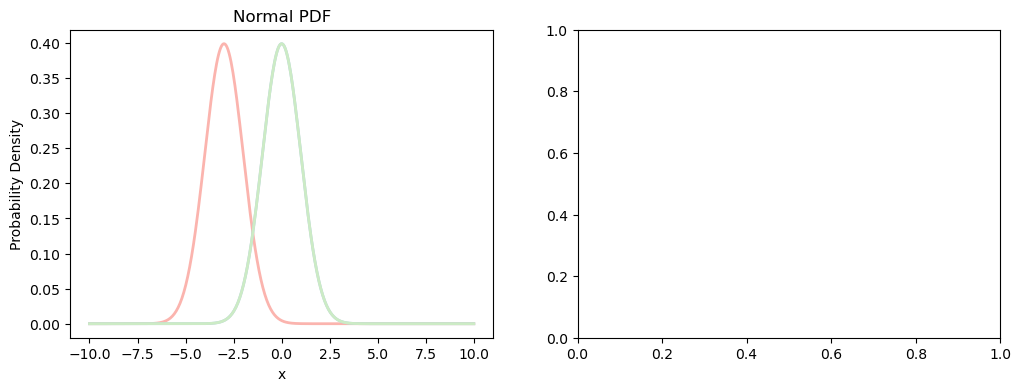

In [35]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes = axes.flatten()
PALETTE = plt.cm.Pastel1.colors
x = np.linspace(-10, 10, 400)

for (m, s, c) in [(-3, 1, PALETTE[0]), (0, 1, PALETTE[1]), (0, 1, PALETTE[2])]:
    axes[0].plot(x, norm.pdf(x, m, s), color = c, lw = 2)

axes[0].set_title("Normal PDF")
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
plt.show()